**Table of contents**<a id='toc0_'></a>    
- [Modeling PFA of 3 fluorophores at 18 nm](#toc1_)    
  - [Reading data](#toc1_1_)    
  - [Fitting data](#toc1_2_)    
  - [CDF of deltas](#toc1_3_)    
  - [PDF of deltas](#toc1_4_)    
  - [Evaluating the fit to the PFA](#toc1_5_)    
  - [Saving the fit](#toc1_6_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Modeling PFA of 3 fluorophores at 18 nm](#toc0_)

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import rcParams
from scipy.optimize import brentq
from scipy.stats import kstest

import fluopy.distributions as dist
import fluopy.figure as fi
import fluopy.fitting as fitting
import fluopy.routines as rt

%load_ext autoreload
%autoreload 2

num_f = 3
distance = "18nm"
reading_from = (
    rf"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\0_4_multi_f_PFA\{num_f}F"
)
saving_to = rf"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\0_5_modeling\{num_f}F\{distance}"

## <a id='toc1_1_'></a>[Reading data](#toc0_)

In [2]:
n_runs = 500
total_photons = 4.5e8  # n runs where all fluorophores of the current bleaching index
# photobleach
photons_per_f = total_photons / n_runs  # maximum number of photons per bleaching event

In [3]:
bleaching_times = np.load(reading_from + f"/bleaching_times_{distance}.npy")
delta_bleaching_times = rt.get_delta_bleaching_times(bleaching_times)

rel_num_not_observed = [
    1 - delta.size / bleaching_times.shape[0] for delta in delta_bleaching_times
]

rel_num_not_observed_all = np.sum(rel_num_not_observed) / len(rel_num_not_observed)
num_not_observed_all = (
    rel_num_not_observed_all * total_photons * bleaching_times.shape[1]
)

fair_num_not_observed = []
fair_rel_num_not_observed = []
for i, delta in enumerate(delta_bleaching_times):
    if i == 0:
        size = bleaching_times.shape[0]
    else:
        size = delta_bleaching_times[i - 1].size
    curr_size = delta_bleaching_times[i].size
    fair_num_not_observed.append((size - curr_size) * photons_per_f)
    fair_rel_num_not_observed.append(1 - delta.size / size)
# the fair_rel_num_not_observed or in general the rel_num_not_observed
# can be used via fair_rel_num / (1-fair_rel_num), which results in a factor with which
# the number of observed events has to be multiplied to get the number of missed events
# however if rel_num is 1, this factor becomes infinite, thats why the photon_per_f
# approach is better here

In [ ]:
x = np.linspace(0, 300, 300001)
rng = np.random.default_rng(42)
fingerprint = pd.Series(np.zeros(300001), np.round(x, decimals=12), dtype=np.int32)
bleaching_times_index = 0
bin_edges_log = np.logspace(np.log10(0.01), np.log10(300), 100)
photon_arrival_times_log = np.zeros(len(bin_edges_log) - 1, dtype=int)
delta_photon_arrival_times_binned = [
    np.zeros(len(bin_edges_log) - 1, dtype=int) for _ in range(num_f)
]
rvs = []
for file in Path(reading_from).iterdir():
    if file.suffix == ".parquet" and distance in file.name:
        df = pd.read_parquet(file)
        fingerprint += df.sum(axis=1)
        for i in range(len(df.columns)):
            start_index = 0
            for n in range(num_f):
                time_point = bleaching_times[bleaching_times_index + i, n]
                if not np.isnan(time_point):
                    end_index = (
                        np.searchsorted(
                            df.iloc[:, i].index.values, time_point, side="right"
                        )
                        + 1
                    )
                else:
                    end_index = df.index.size
                data = np.repeat(
                    df.iloc[:, i].index.values[start_index:end_index],
                    df.iloc[:, i].iloc[start_index:end_index].values.astype(int),
                )
                rvs.extend(rng.choice(data, size=int(0.1 * data.size), replace=True))
                hist_log, _ = np.histogram(data, bins=bin_edges_log)
                photon_arrival_times_log += hist_log
                if data.size != 0:
                    delta_data = data - df.index.values[start_index] + 0.01
                    delta_hist, _ = np.histogram(delta_data, bins=bin_edges_log)
                    delta_photon_arrival_times_binned[n] += delta_hist
                start_index = end_index
        bleaching_times_index += 50

fingerprint = fingerprint.cumsum() / fingerprint.sum()

In [5]:
for delta in delta_photon_arrival_times_binned:
    print(f"{delta.sum():.2e}")

1.37e+08
1.75e+07
9.80e+05


## <a id='toc1_2_'></a>[Fitting data](#toc0_)

In [ ]:
z = -1
rng = np.random.default_rng(42)
result = fitting.fit_multiple_mixture_v1(
    datasets=delta_photon_arrival_times_binned,
    bin_edges=bin_edges_log,
    maxiter=1000,
    popsize=200,
    norm=False,
    constr=True,
    disp=False,
    z=z,
    counts_not_observed=fair_num_not_observed,
    seed=rng,
    polish=False,
    pfa_counts=photon_arrival_times_log,
    pfa_bin_edges=bin_edges_log,
    pfa_counts_not_observed=num_not_observed_all,
)

parameter_dict_pfa = fitting.prepare_pfa_parameters(z=z, n=num_f, params=result.x)
parameter_dict_exp_mixture = fitting.prepare_exp_mixture_parameters(
    z=z, n=num_f, params=result.x
)

## <a id='toc1_3_'></a>[CDF of deltas](#toc0_)

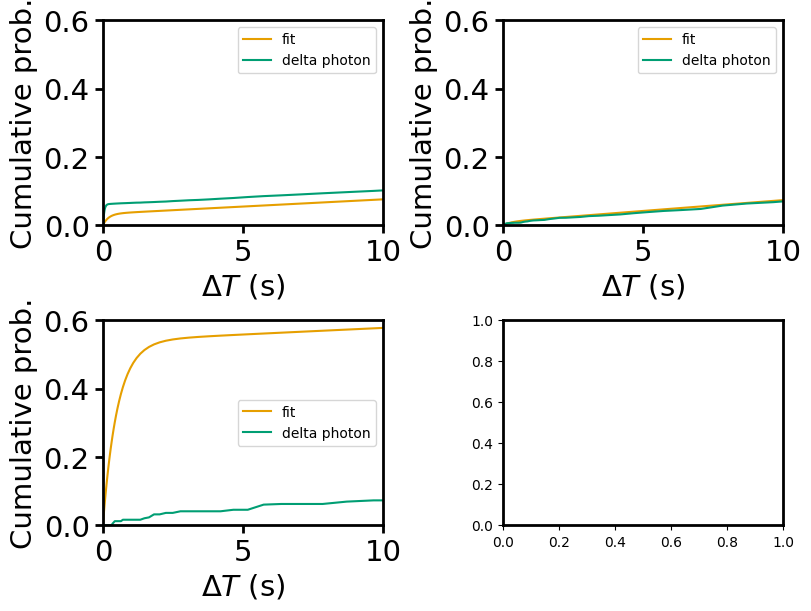

In [7]:
rcParams["axes.linewidth"] = 2
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]
fig, ax = plt.subplots(2, 2, figsize=(8, 6), layout="constrained")
for i, delta in enumerate(delta_photon_arrival_times_binned):
    axis = ax.flatten()[i]
    bin_widths = np.diff(bin_edges_log)
    bin_centers = (bin_edges_log[:-1] + bin_edges_log[1:]) / 2
    bin_centers = np.insert(bin_centers, 0, 0)
    cdf = np.cumsum(delta) / delta.sum()
    cdf = np.insert(cdf, 0, 0)
    if i != 0:
        pfa_cdf_part = dist.Photoswitching_fingerprint_model(
            params=parameter_dict_pfa, domain=(0, 300)
        ).cdf_part
        cdf_part_index = i - 1
        cdf_marg = dist.ExponentialMixtureMarginalModel(
            parameter_dict_exp_mixture[i], pfa_cdf_part, cdf_part_index, 300
        ).cdf
        use = cdf_marg
    else:
        cdf_non_marg = dist.ExponentialMixtureModel(
            parameter_dict_exp_mixture[i], domain=(0, 300)
        ).cdf
        use = cdf_non_marg
    fi.universal_figure(
        data=[
            bin_edges_log,
            use(bin_edges_log),
        ],
        axes=axis,
        color=orange,
        label="fit",
    )
    fi.universal_figure(
        data=[bin_edges_log, cdf],
        axes=axis,
        color=green,
        label="delta photon",
        xlabel=r"$\Delta T$ (s)",
        ylabel="Cumulative prob.",
        legend=True,
        xlim=(0, 10),
        ylim=(0, 0.6),
    )

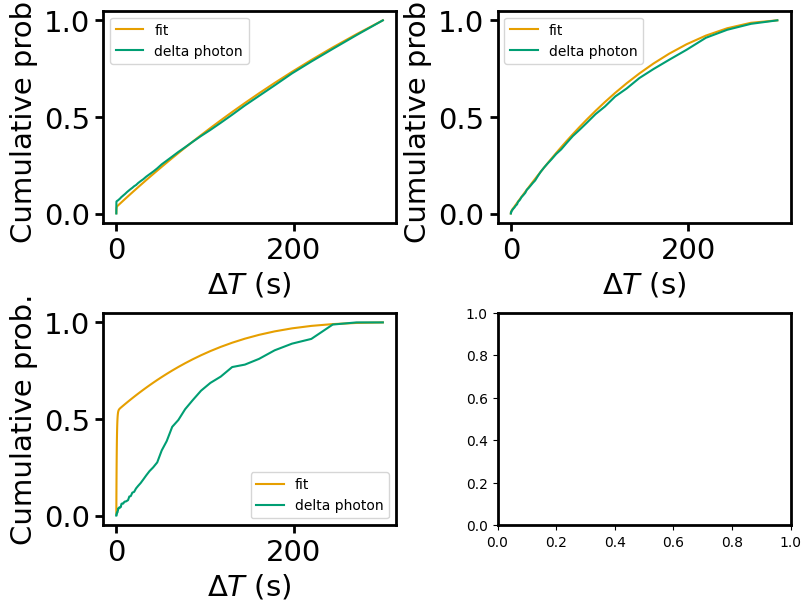

In [8]:
rcParams["axes.linewidth"] = 2
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]
fig, ax = plt.subplots(2, 2, figsize=(8, 6), layout="constrained")
for i, delta in enumerate(delta_photon_arrival_times_binned):
    axis = ax.flatten()[i]
    bin_widths = np.diff(bin_edges_log)
    bin_centers = (bin_edges_log[:-1] + bin_edges_log[1:]) / 2
    bin_centers = np.insert(bin_centers, 0, 0)
    cdf = np.cumsum(delta) / delta.sum()
    cdf = np.insert(cdf, 0, 0)
    if i != 0:
        pfa_cdf_part = dist.Photoswitching_fingerprint_model(
            params=parameter_dict_pfa, domain=(0, 300)
        ).cdf_part
        cdf_part_index = i - 1
        cdf_marg = dist.ExponentialMixtureMarginalModel(
            parameter_dict_exp_mixture[i], pfa_cdf_part, cdf_part_index, 300
        ).cdf
        use = cdf_marg
    else:
        cdf_non_marg = dist.ExponentialMixtureModel(
            parameter_dict_exp_mixture[i], domain=(0, 300)
        ).cdf
        use = cdf_non_marg
    fi.universal_figure(
        data=[
            bin_edges_log,
            use(bin_edges_log),
        ],
        axes=axis,
        color=orange,
        label="fit",
    )
    fi.universal_figure(
        data=[bin_edges_log, cdf],
        axes=axis,
        color=green,
        label="delta photon",
        xlabel=r"$\Delta T$ (s)",
        ylabel="Cumulative prob.",
        legend=True,
    )

fig.savefig(
    saving_to + r"\delta_photon_fits_cdf.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.1,
)

## <a id='toc1_4_'></a>[PDF of deltas](#toc0_)

c:\Users\vie43sq\data_vincent\GitHub\Photoswitching\.venv\Lib\site-packages\numpy\lib\_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


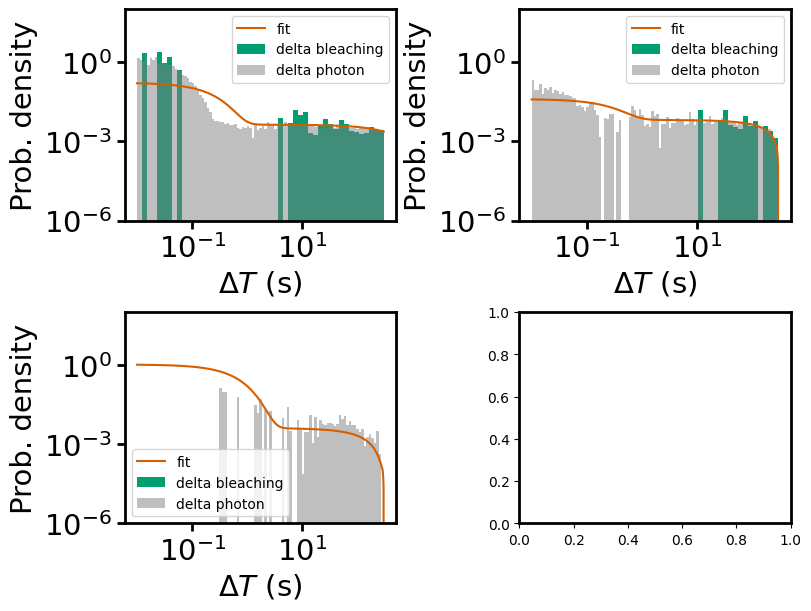

In [9]:
fig, ax = plt.subplots(2, 2, figsize=(8, 6), layout="constrained")
for i, delta in enumerate(delta_photon_arrival_times_binned):
    axis = ax.flatten()[i]
    bin_widths = np.diff(bin_edges_log)
    density = delta / (delta.sum() * bin_widths)
    bin_centers = (bin_edges_log[:-1] + bin_edges_log[1:]) / 2
    # bin_centers = np.insert(bin_centers, 0, 0)
    x = np.logspace(np.log10(0.01), np.log10(300), 1000)
    bins = np.logspace(np.log10(0.01), np.log10(300), 50)
    if i != 0:
        pfa_cdf_part = dist.Photoswitching_fingerprint_model(
            params=parameter_dict_pfa, domain=(0, 300)
        ).cdf_part
        cdf_part_index = i - 1
        pdf_marg = dist.ExponentialMixtureMarginalModel(
            parameter_dict_exp_mixture[i], pfa_cdf_part, cdf_part_index, 300
        ).pdf
        use = pdf_marg
    else:
        pdf_non_marg = dist.ExponentialMixtureModel(
            parameter_dict_exp_mixture[i], domain=(0, 300)
        ).pdf
        use = pdf_non_marg
    fi.universal_figure(
        data=[x, use(x)],
        axes=axis,
        color=red,
        label="fit",
    )
    fi.universal_figure(
        type_="hist",
        data=delta_bleaching_times[i],
        axes=axis,
        bins=bins,
        density=True,
        color=green,
        label="delta bleaching",
    )
    fi.universal_figure(
        type_="bar",
        width=bin_widths,
        data=[bin_centers, density],
        axes=axis,
        color="grey",
        label="delta photon",
        xscale="log",
        yscale="log",
        legend=True,
        ylim=[1e-6, 1e2],
        alpha=0.5,
        ylabel="Prob. density",
        xlabel=r"$\Delta T$ (s)",
    )

fig.savefig(
    saving_to + r"\delta_photon_fits_pdf.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.1,
)

## <a id='toc1_5_'></a>[Evaluating the fit to the PFA](#toc0_)

In [10]:
x = np.linspace(0, 300, 300001)
cdf = dist.Photoswitching_fingerprint_model(parameter_dict_pfa, None, (0, 300)).cdf
pdf = dist.Photoswitching_fingerprint_model(parameter_dict_pfa, None, (0, 300)).pdf
# kstest
print(kstest(rvs, cdf).statistic)
# W1
cdf_diff = np.abs(fingerprint.values - cdf(fingerprint.index))
W1 = np.trapezoid(cdf_diff, fingerprint.index)
print(W1)

0.03897221879350265
2.0772629517690473


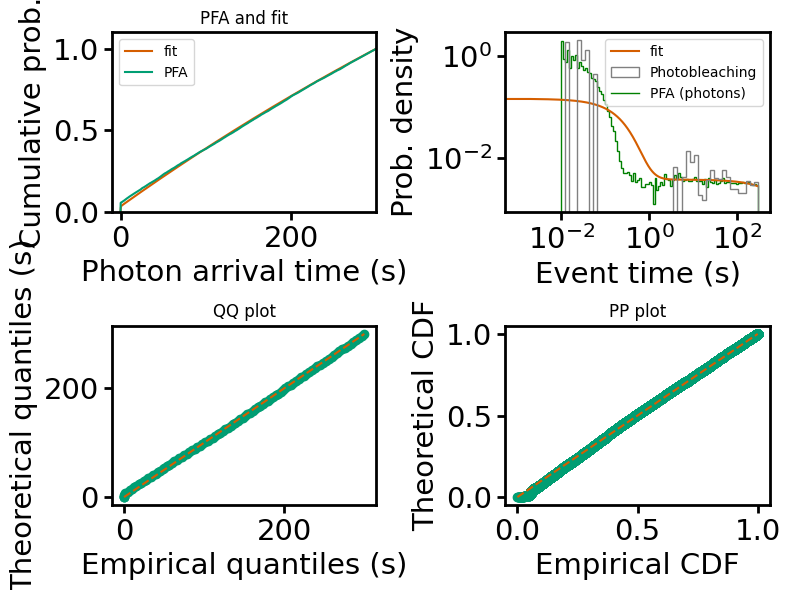

In [11]:
gs = plt.GridSpec(2, 2)
fig = plt.figure(figsize=(8, 6))

ax1 = fig.add_subplot(gs[0, 0])
fi.universal_figure(
    data=[x, cdf(x)],
    color=red,
    label="fit",
    axes=ax1,
)
fi.universal_figure(
    data=[fingerprint.index, fingerprint.values],
    axes=ax1,
    color=green,
    ylabel="Cumulative prob.",
    xlabel="Photon arrival time (s)",
    xlim=[-10, 300],
    ylim=[0, 1.1],
    label="PFA",
    legend=True,
)
ax1.set_title("PFA and fit")

ax2 = fig.add_subplot(gs[0, 1])
fi.universal_figure(
    data=[x, pdf(x)],
    color=red,
    label="fit",
    axes=ax2,
)
data = bleaching_times.flatten()
data = data[~np.isnan(data)]
bins = np.logspace(np.log10(0.01), np.log10(300), 50)
fi.universal_figure(
    type_="hist",
    histtype="step",
    data=data,
    axes=ax2,
    bins=bins,
    density=True,
    color="grey",
    label="Photobleaching",
)
bin_widths = np.diff(bin_edges_log)
density = photon_arrival_times_log / (photon_arrival_times_log.sum() * bin_widths)
fi.universal_figure(
    type_="stair",
    data=[bin_edges_log, density],
    axes=ax2,
    xlabel="Event time (s)",
    ylabel="Prob. density",
    xscale="log",
    yscale="log",
    color="green",
    legend=True,
    label="PFA (photons)",
)

# QQ plot
quantiles = []
ps = np.linspace(0.01, 1, 100)
quantiles_ecdfd = np.interp(ps, fingerprint.values, fingerprint.index)
for p in ps:
    q = brentq(
        f=lambda x, p=p: cdf(x) - p, a=0, b=300
    )  # root finding algorithm, such that f(x) = 0
    quantiles.append(q)

ax3 = fig.add_subplot(gs[1, 0])
fi.universal_figure(
    type_="scatter",
    data=[quantiles_ecdfd, quantiles],
    axes=ax3,
    xlabel="Empirical quantiles (s)",
    ylabel="Theoretical quantiles (s)",
    color=green,
)
ax3.plot(np.linspace(0, 300, 100), np.linspace(0, 300, 100), color=red, linestyle="--")
ax3.set_title("QQ plot")


# PP plot
ax4 = fig.add_subplot(gs[1, 1])
fi.universal_figure(
    type_="scatter",
    data=[fingerprint.values, cdf(fingerprint.index)],
    axes=ax4,
    xlabel="Empirical CDF",
    ylabel="Theoretical CDF",
    color=green,
)
ax4.plot(np.linspace(0, 1, 100), np.linspace(0, 1, 100), color=red, linestyle="--")
ax4.set_title("PP plot")

fig.tight_layout()

fig.savefig(saving_to + r"\PFA_fits.png", dpi=300, bbox_inches="tight", pad_inches=0.1)

## <a id='toc1_6_'></a>[Saving the fit](#toc0_)

In [ ]:
fitting.save_as_array(
    parameter_dict_pfa, saving_to + rf"\parameters_{num_f}F_{distance}.npy"
)